In [405]:
import numpy as np
import matplotlib.pyplot as plt

In [406]:
# Function to generate energies and momenta of daughter particles from the dacay of a parent particle at rest
def decay_generator(M, m):
    # Generate energies and momenta
    E = E = M/2
    p_val = 0.5 * np.sqrt(M**2 - 4* m**2)

    cos_theta = np.random.uniform(-1, 1)
    theta = np.arccos(cos_theta)
    phi = np.random.uniform(0, 2*np.pi)

    px = p_val * np.sin(theta) * np.cos(phi)
    py = p_val * np.sin(theta) * np.sin(phi)
    pz = p_val * np.cos(theta)

    p1 = np.array([E, px, py, pz])
    p2 = np.array([E, -px, -py, -pz])

    return p1, p2

def invariant_mass(p1, p2):
    E = p1[0] + p2[0]
    px = p1[1] + p2[1]
    py = p1[2] + p2[2]
    pz = p1[3] + p2[3]

    return np.sqrt(E**2 - px**2 - py**2 - pz**2)

In [407]:
# Function to create N samples of invariant masses from the dacay of a particle of mass M at rest (without smearing)
def sample_M(M, m, N_samples):
    masses_sig = []
    for _ in range(N_samples):
        p1, p2 = decay_generator(M, m)
        inv_m = invariant_mass(p1, p2)
        masses_sig.append(inv_m)
    return masses_sig

In [408]:
#Function to create N samples of invariant masses from the decay of a particle of mass M at rest (with smearing)
def sample_M_smeared(M, m, N_samples, rel_sigma=0.03):
   
    masses_smear = []

    for _ in range(N_samples):
        p1, p2 = decay_generator(M, m)

        px1_s = np.random.normal(p1[1], abs(p1[1]) * rel_sigma)
        py1_s = np.random.normal(p1[2], abs(p1[2]) * rel_sigma)
        pz1_s = np.random.normal(p1[3], abs(p1[3]) * rel_sigma)
        px2_s = np.random.normal(p2[1], abs(p2[1]) * rel_sigma)
        py2_s = np.random.normal(p2[2], abs(p2[2]) * rel_sigma)
        pz2_s = np.random.normal(p2[3], abs(p2[3]) * rel_sigma)

        p1_smear = [_, px1_s, py1_s, pz1_s]
        p2_smear = [_, px2_s, py2_s, pz2_s]

        p_squared = p1_smear[1]**2 + p1_smear[2]**2 + p1_smear[3]**2
        E = np.sqrt(p_squared + m**2)
        p1_smear[0] = E
        p2_smear[0] = E

        inv_m = invariant_mass(p1_smear, p2_smear)
        masses_smear.append(inv_m)

    return masses_smear

In [409]:
# Function to create N samples of daughter particles momentum distribution from the decay of a particle of mass M at rest (without smearing)
def sample_p(M, m, N_samples):
    momentum_sig = []
    for _ in range(N_samples):
        p1, p2 = decay_generator(M, m)
        p_val = np.sqrt(p1[1]**2 + p1[2]**2 + p1[3]**2)
        momentum_sig.append(p_val)
    return momentum_sig

In [410]:
#Function to create N samples of daughter particles momentum distribution from the decay of a particle of mass M at rest (with smearing)
def sample_p_smeared(M, m, N_samples, rel_sigma=0.03):
   
    momentum_smear = []

    for _ in range(N_samples):
        p1, p2 = decay_generator(M, m)

        px_s = np.random.normal(p1[1], abs(p1[1]) * rel_sigma)
        py_s = np.random.normal(p1[2], abs(p1[2]) * rel_sigma)
        pz_s = np.random.normal(p1[3], abs(p1[3]) * rel_sigma)

        p_val_smear = np.sqrt(px_s**2 + py_s**2 + pz_s**2)
        momentum_smear.append(p_val_smear)
    return momentum_smear

In [411]:
# Function to create N samples of invariant masses from the two photon interaction with exponential mass distribution
def sample_exp(M_max, m, N_samples):
    masses_bkg = []
    for _ in range(N_samples):
        while True:
            M = np.random.exponential(scale=1.0) + (2*m)
            if M < M_max:
                break
        p1, p2 = decay_generator(M, m)
        inv_m = invariant_mass(p1, p2)
        masses_bkg.append(inv_m)
    return masses_bkg

In [412]:
# Function to create N samples of daughter particles momentum distribution from the two photon interaction with exponential mass distribution
def sample_p_exp(M_max, m, N_samples):
    momentum_bkg = []
    for _ in range(N_samples):
        while True:
            M = np.random.exponential(scale=1.0) + (2*m)
            if M < M_max:
                break
        p1, p2 = decay_generator(M, m)
        p_val = np.sqrt(p1[1]**2 + p1[2]**2 + p1[3]**2)
        momentum_bkg.append(p_val)
    return momentum_bkg

In [413]:
# Particle masses in [GeV]
particles = {
  "J/psi": 3.1,
  "p": 0.938,
  "mu": 0.105,
  "e" : 0.000511,
  "K_0" : 0.498,
  "K_+" : 0.494,
  "phi" : 1.019,
  "psip" : 3.686
}

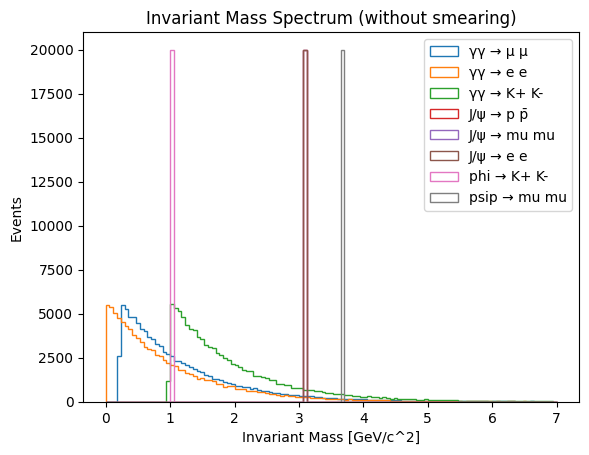

In [414]:
# Plot the combined invariant mass distribution for all cases (without smearing)
bins = np.linspace(0, 7, 120)

plt.hist(sample_exp(7, particles['mu'], 100000), bins=bins, histtype='step', label='γγ → μ μ')
plt.hist(sample_exp(7, particles['e'], 100000), bins=bins, histtype='step', label='γγ → e e')
plt.hist(sample_exp(7, particles['K_+'], 100000), bins=bins, histtype='step', label='γγ → K+ K-')

plt.hist(sample_M(particles['J/psi'], particles['p'], 20000), bins=bins, histtype='step', label='J/ψ → p p̄')
plt.hist(sample_M(particles['J/psi'], particles['mu'], 20000), bins=bins, histtype='step', label='J/ψ → mu mu')
plt.hist(sample_M(particles['J/psi'], particles['e'], 20000), bins=bins, histtype='step', label='J/ψ → e e')
plt.hist(sample_M(particles['phi'], particles['K_+'], 20000), bins=bins, histtype='step', label='phi → K+ K-')
plt.hist(sample_M(particles['psip'], particles['mu'], 20000), bins=bins, histtype='step', label='psip → mu mu')

plt.xlabel("Invariant Mass [GeV/c^2]")
plt.ylabel("Events")
plt.title("Invariant Mass Spectrum (without smearing)")
plt.legend()
plt.show()

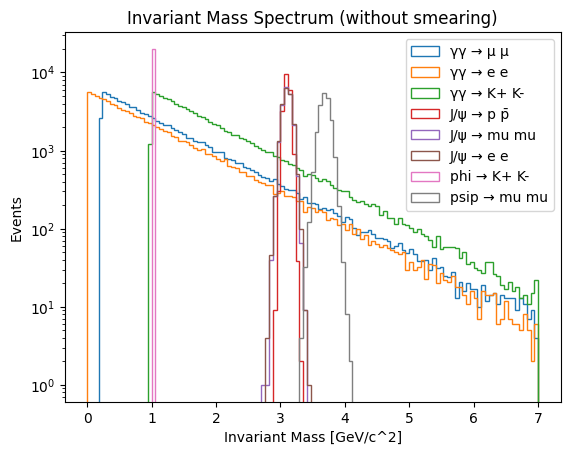

In [415]:
# Plot the combined invariant mass distribution for all cases (with smearing applied)
bins = np.linspace(0, 7, 120)

plt.hist(sample_exp(7, particles['mu'], 100000), bins=bins, histtype='step', label='γγ → μ μ')
plt.hist(sample_exp(7, particles['e'], 100000), bins=bins, histtype='step', label='γγ → e e')
plt.hist(sample_exp(7, particles['K_+'], 100000), bins=bins, histtype='step', label='γγ → K+ K-')

plt.hist(sample_M_smeared(particles['J/psi'], particles['p'], 20000), bins=bins, histtype='step', label='J/ψ → p p̄')
plt.hist(sample_M_smeared(particles['J/psi'], particles['mu'], 20000), bins=bins, histtype='step', label='J/ψ → mu mu')
plt.hist(sample_M_smeared(particles['J/psi'], particles['e'], 20000), bins=bins, histtype='step', label='J/ψ → e e')
plt.hist(sample_M_smeared(particles['phi'], particles['K_+'], 20000), bins=bins, histtype='step', label='phi → K+ K-')
plt.hist(sample_M_smeared(particles['psip'], particles['mu'], 20000), bins=bins, histtype='step', label='psip → mu mu')

plt.xlabel("Invariant Mass [GeV/c^2]")
plt.ylabel("Events")
plt.title("Invariant Mass Spectrum (without smearing)")
plt.yscale('log')
plt.legend()
plt.show()

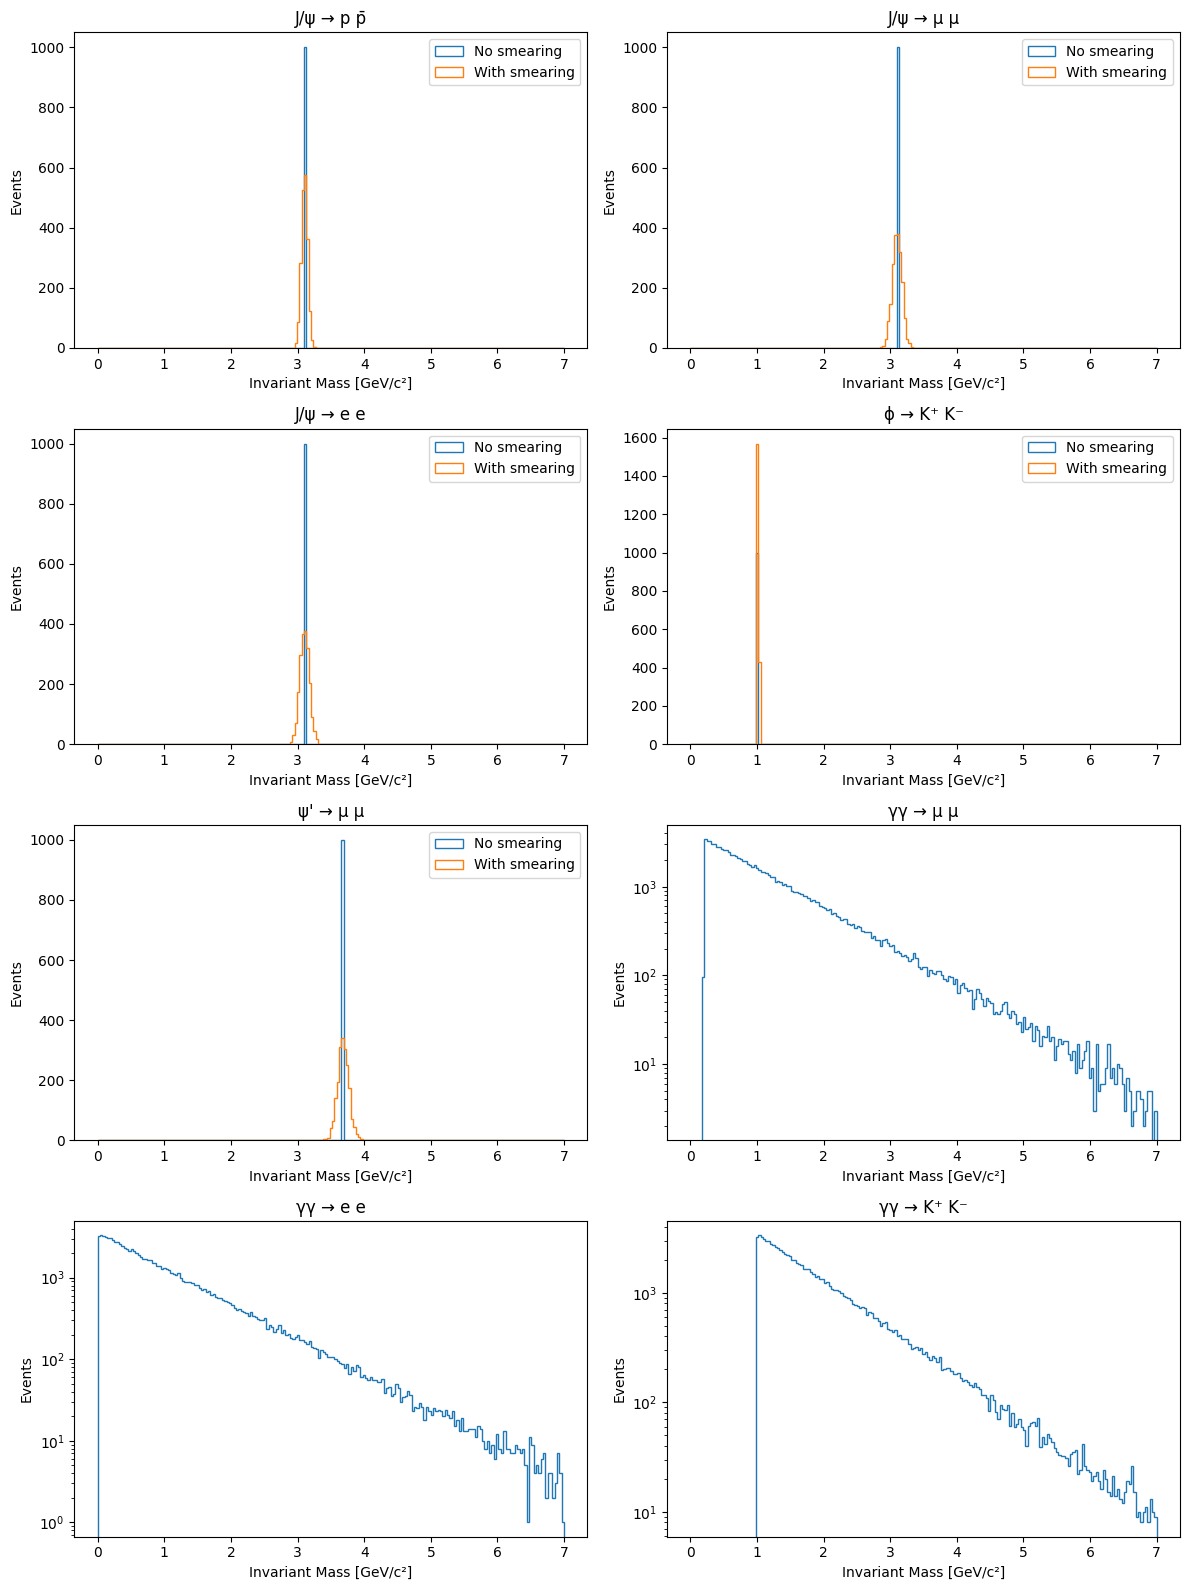

In [416]:
# Resonance reactions (with/without smearing)
resonances = [
    ("J/ψ → p p̄", particles['J/psi'], particles['p']),
    ("J/ψ → μ μ", particles['J/psi'], particles['mu']),
    ("J/ψ → e e", particles['J/psi'], particles['e']),
    ("ϕ → K⁺ K⁻", particles['phi'], particles['K_+']),
    ("ψ' → μ μ", particles['psip'], particles['mu']),
]

# Continuum γγ reactions (no smearing, log scale)
continuum = [
    ("γγ → μ μ", particles['mu']),
    ("γγ → e e", particles['e']),
    ("γγ → K⁺ K⁻", particles['K_+']),
]

bins = np.linspace(0, 7, 200)

# total number of plots
n = len(resonances) + len(continuum)

ncols = 2
nrows = int(np.ceil(n / ncols))

fig, axes = plt.subplots(nrows, ncols, figsize=(12, 4*nrows))
axes = axes.flatten()

i = 0

# First: resonance plots (overlay)
for label, M, m in resonances:
    
    masses_no = sample_M(M, m, 1000)
    masses_sm = sample_M_smeared(M, m, 2000, rel_sigma=0.03)
    
    ax = axes[i]
    ax.hist(masses_no, bins=bins, histtype='step', label='No smearing')
    ax.hist(masses_sm, bins=bins, histtype='step', label='With smearing')
    
    ax.set_title(label)
    ax.set_xlabel("Invariant Mass [GeV/c²]")
    ax.set_ylabel("Events")
    ax.legend()
    
    i += 1

# Then: γγ spectra (NO smearing, LOG scale)
for label, m in continuum:
    
    masses = sample_exp(7.0, m, 100000)
    
    ax = axes[i]
    ax.hist(masses, bins=bins, histtype='step')
    
    ax.set_title(label)
    ax.set_xlabel("Invariant Mass [GeV/c²]")
    ax.set_ylabel("Events")
    ax.set_yscale('log')
    
    i += 1

# Remove empty axes if any
for j in range(i, len(axes)):
    fig.delaxes(axes[j])

plt.tight_layout()
plt.show()


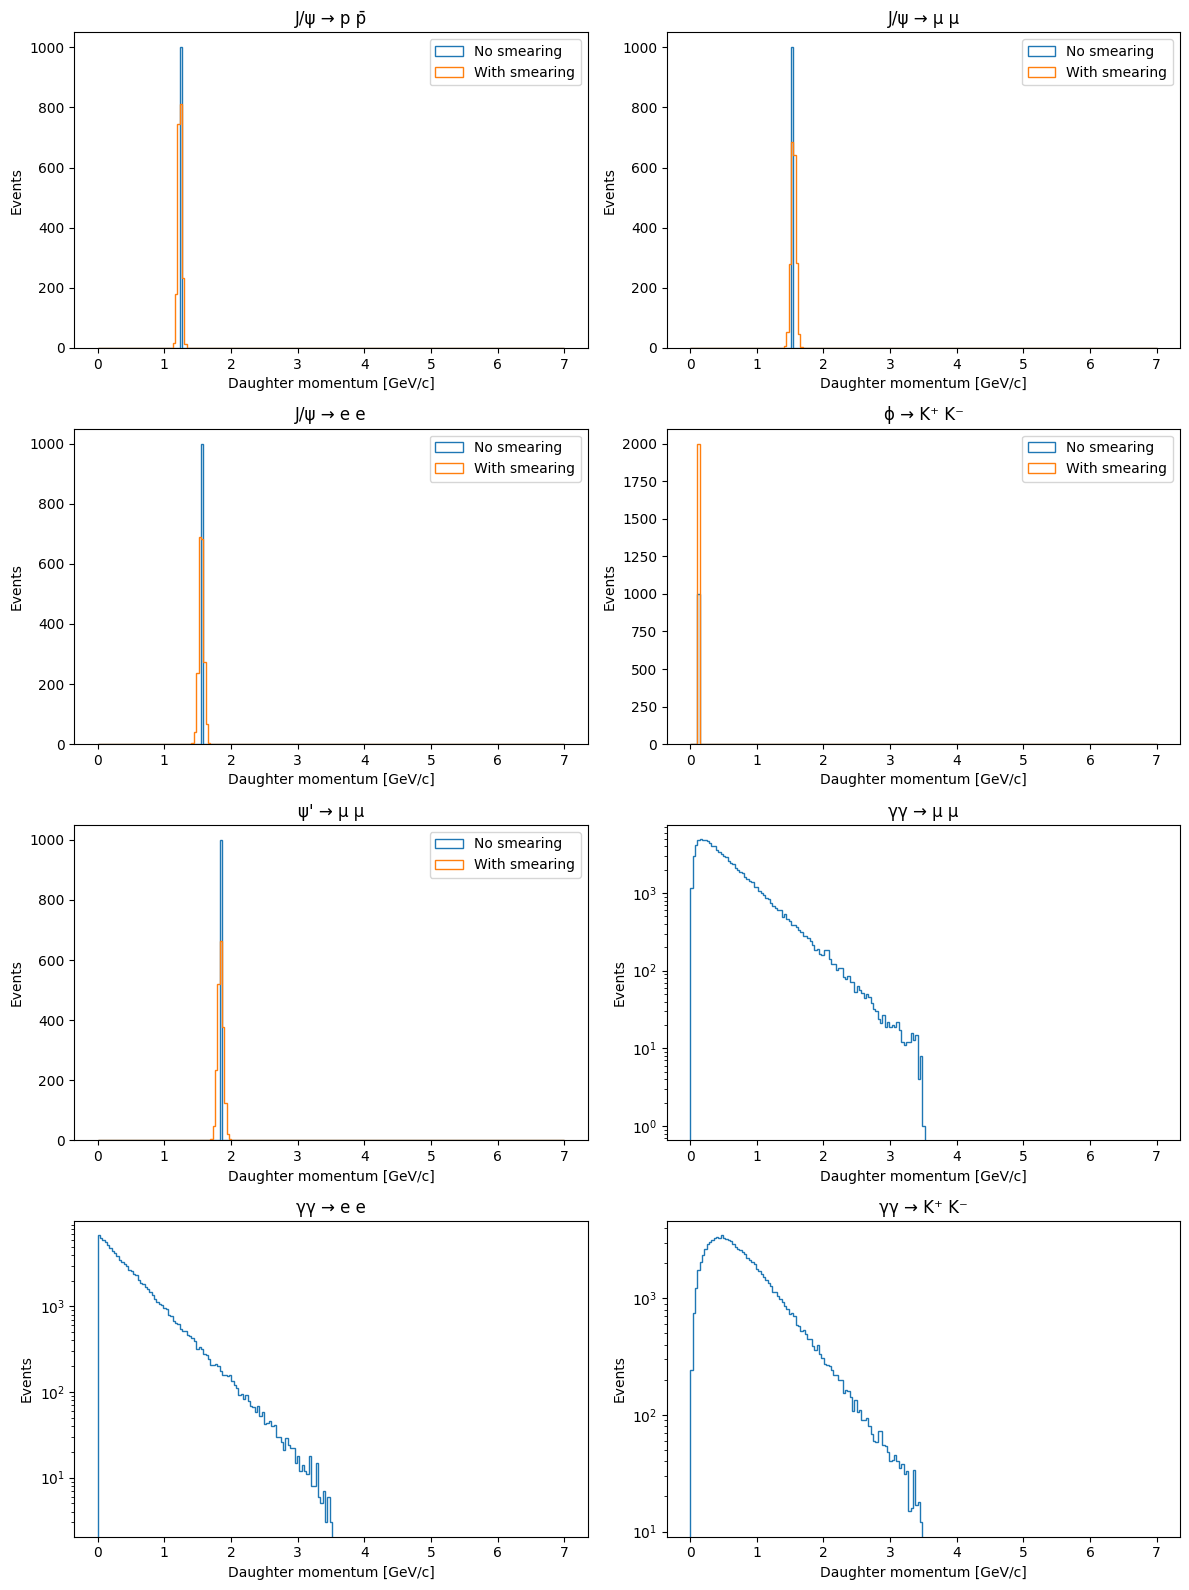

In [417]:
# total number of plots
n = len(resonances) + len(continuum)

ncols = 2
nrows = int(np.ceil(n / ncols))

fig, axes = plt.subplots(nrows, ncols, figsize=(12, 4*nrows))
axes = axes.flatten()

i = 0

# First: resonance plots (overlay)
for label, M, m in resonances:
    
    masses_no = sample_p(M, m, 1000)
    masses_sm = sample_p_smeared(M, m, 2000, rel_sigma=0.03)
    
    ax = axes[i]
    ax.hist(masses_no, bins=bins, histtype='step', label='No smearing')
    ax.hist(masses_sm, bins=bins, histtype='step', label='With smearing')
    
    ax.set_title(label)
    ax.set_xlabel("Daughter momentum [GeV/c]")
    ax.set_ylabel("Events")
    ax.legend()
    
    i += 1

# Then: γγ spectra (NO smearing, LOG scale)
for label, m in continuum:
    
    masses = sample_p_exp(7.0, m, 100000)
    
    ax = axes[i]
    ax.hist(masses, bins=bins, histtype='step')
    
    ax.set_title(label)
    ax.set_xlabel("Daughter momentum [GeV/c]")
    ax.set_ylabel("Events")
    ax.set_yscale('log')
    
    i += 1

# Remove empty axes if any
for j in range(i, len(axes)):
    fig.delaxes(axes[j])

plt.tight_layout()
plt.show()